In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\heart\quantum_6g_ai")
RESULTS_DIR = PROJECT_ROOT / "results"

TRAIN_PATH = RESULTS_DIR / "train_scaled.csv"
TEST_PATH = RESULTS_DIR / "test_scaled.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

FEATURE_COLUMNS = [
    "SINR",
    "RSRP",
    "Latency",
    "Packet_Loss",
    "Throughput",
    "Interference",
    "Resource_Load",
    "Trust_Score",
    "Risk_Score"
]

TARGET_COLUMN = "Label"

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET_COLUMN].copy()

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (800, 9)
Testing : (200, 9)


In [2]:
correlation_df = X_train.copy()
correlation_df["Label"] = y_train.values

corr_with_label = (
    correlation_df
    .corr(numeric_only=True)["Label"]
    .drop("Label")
    .sort_values(key=np.abs, ascending=False)
)

print("Feature correlation with Label:")
print(corr_with_label.to_string())

Feature correlation with Label:
Risk_Score       0.738671
Trust_Score     -0.738671
Interference     0.207074
Latency          0.198662
Resource_Load    0.189248
Throughput      -0.075793
SINR            -0.028250
RSRP             0.009306
Packet_Loss     -0.007326


In [3]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print("Mutual Information scores:")
print(
    mi_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

Mutual Information scores:
      Feature  Mutual_Information
  Trust_Score            0.408443
   Risk_Score            0.408443
  Packet_Loss            0.047242
 Interference            0.031897
Resource_Load            0.031539
      Latency            0.016703
   Throughput            0.016240
         SINR            0.003727
         RSRP            0.000000


In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Coefficient": lr.coef_[0],
    "Abs_Coefficient": np.abs(lr.coef_[0])
}).sort_values(
    "Abs_Coefficient",
    ascending=False
)

print("Logistic Regression feature importance:")
print(
    importance_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

Logistic Regression feature importance:
      Feature  Coefficient  Abs_Coefficient
   Risk_Score     4.241474         4.241474
  Trust_Score    -4.241474         4.241474
Resource_Load     2.386693         2.386693
      Latency     2.317117         2.317117
 Interference     2.120217         2.120217
  Packet_Loss     0.482674         0.482674
   Throughput    -0.095489         0.095489
         RSRP     0.079952         0.079952
         SINR    -0.043041         0.043041


In [5]:
QUANTUM_FEATURES = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

X_train_q = X_train[QUANTUM_FEATURES].copy()
X_test_q = X_test[QUANTUM_FEATURES].copy()

print("Selected quantum features:")
for i, feature in enumerate(QUANTUM_FEATURES, 1):
    print(f"{i}. {feature}")

print("\nQuantum training matrix:", X_train_q.shape)
print("Quantum testing matrix :", X_test_q.shape)

Selected quantum features:
1. Trust_Score
2. Risk_Score
3. Interference
4. Resource_Load

Quantum training matrix: (800, 4)
Quantum testing matrix : (200, 4)


In [6]:
from sklearn.preprocessing import MinMaxScaler

angle_scaler = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_angles = angle_scaler.fit_transform(X_train_q)
X_test_angles = angle_scaler.transform(X_test_q)

print("Angle-encoded training shape:", X_train_angles.shape)
print("Angle-encoded testing shape :", X_test_angles.shape)

print("\nTraining angle ranges:")

for i, feature in enumerate(QUANTUM_FEATURES):
    print(
        f"{feature:16s}: "
        f"min={X_train_angles[:, i].min(): .4f}, "
        f"max={X_train_angles[:, i].max(): .4f}"
    )

Angle-encoded training shape: (800, 4)
Angle-encoded testing shape : (200, 4)

Training angle ranges:
Trust_Score     : min=-3.1416, max= 3.1416
Risk_Score      : min=-3.1416, max= 3.1416
Interference    : min=-3.1416, max= 3.1416
Resource_Load   : min=-3.1416, max= 3.1416


In [7]:
angle_df = pd.DataFrame(
    X_train_angles,
    columns=QUANTUM_FEATURES
)

print("First 5 angle-encoded samples:")
print(
    angle_df.head().to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

First 5 angle-encoded samples:
 Trust_Score  Risk_Score  Interference  Resource_Load
      0.7373     -0.7373       -0.3343         1.2797
      2.3469     -2.3469       -0.7110        -3.1416
     -0.3558      0.3558       -0.3932         2.1117
      2.6462     -2.6462       -0.4422         0.4739
      1.2545     -1.2545        0.3591         1.8906


In [8]:
TRAIN_Q_PATH = RESULTS_DIR / "quantum_train_features.csv"
TEST_Q_PATH = RESULTS_DIR / "quantum_test_features.csv"

quantum_train_df = pd.DataFrame(
    X_train_angles,
    columns=QUANTUM_FEATURES
)

quantum_train_df["Label"] = y_train.to_numpy()

quantum_test_df = pd.DataFrame(
    X_test_angles,
    columns=QUANTUM_FEATURES
)

quantum_test_df["Label"] = y_test.to_numpy()

quantum_train_df.to_csv(
    TRAIN_Q_PATH,
    index=False
)

quantum_test_df.to_csv(
    TEST_Q_PATH,
    index=False
)

print("Quantum feature datasets saved:")
print(TRAIN_Q_PATH)
print(TEST_Q_PATH)

Quantum feature datasets saved:
C:\Users\heart\quantum_6g_ai\results\quantum_train_features.csv
C:\Users\heart\quantum_6g_ai\results\quantum_test_features.csv


In [9]:
from qiskit import QuantumCircuit
import numpy as np

def create_feature_map(feature_angles):
    """
    4-qubit quantum feature map.

    q0 -> Trust_Score
    q1 -> Risk_Score
    q2 -> Interference
    q3 -> Resource_Load

    Encoding:
        Ry(angle) + Rz(angle)

    Entanglement:
        Linear CNOT chain
    """

    qc = QuantumCircuit(4)

    # Feature encoding
    for qubit, angle in enumerate(feature_angles):
        qc.ry(angle, qubit)
        qc.rz(angle, qubit)

    # Entanglement
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 3)

    return qc


# Encode first training sample
sample_angles = X_train_angles[0]

feature_map = create_feature_map(sample_angles)

print("Selected features:")
for i, (feature, angle) in enumerate(
    zip(QUANTUM_FEATURES, sample_angles)
):
    print(f"q{i}: {feature:16s} angle={angle:.6f}")

print("\nQuantum Feature Map:")
print(feature_map.draw("text"))

Selected features:
q0: Trust_Score      angle=0.737309
q1: Risk_Score       angle=-0.737309
q2: Interference     angle=-0.334270
q3: Resource_Load    angle=1.279721

Quantum Feature Map:
     ┌─────────────┐ ┌─────────────┐                
q_0: ┤ Ry(0.73731) ├─┤ Rz(0.73731) ├───■────────────
     ├─────────────┴┐├─────────────┴┐┌─┴─┐          
q_1: ┤ Ry(-0.73731) ├┤ Rz(-0.73731) ├┤ X ├──■───────
     ├──────────────┤├──────────────┤└───┘┌─┴─┐     
q_2: ┤ Ry(-0.33427) ├┤ Rz(-0.33427) ├─────┤ X ├──■──
     └┬────────────┬┘└┬────────────┬┘     └───┘┌─┴─┐
q_3: ─┤ Ry(1.2797) ├──┤ Rz(1.2797) ├───────────┤ X ├
      └────────────┘  └────────────┘           └───┘


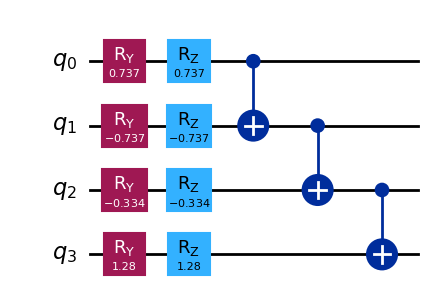

In [10]:
feature_map.draw("mpl")

In [11]:
print(feature_map.draw("text"))

     ┌─────────────┐ ┌─────────────┐                
q_0: ┤ Ry(0.73731) ├─┤ Rz(0.73731) ├───■────────────
     ├─────────────┴┐├─────────────┴┐┌─┴─┐          
q_1: ┤ Ry(-0.73731) ├┤ Rz(-0.73731) ├┤ X ├──■───────
     ├──────────────┤├──────────────┤└───┘┌─┴─┐     
q_2: ┤ Ry(-0.33427) ├┤ Rz(-0.33427) ├─────┤ X ├──■──
     └┬────────────┬┘└┬────────────┬┘     └───┘┌─┴─┐
q_3: ─┤ Ry(1.2797) ├──┤ Rz(1.2797) ├───────────┤ X ├
      └────────────┘  └────────────┘           └───┘


In [12]:
print("=" * 60)
print("QUANTUM FEATURE MAP VALIDATION")
print("=" * 60)

print("Number of qubits :", feature_map.num_qubits)
print("Circuit depth    :", feature_map.depth())
print("Gate counts      :", feature_map.count_ops())

assert feature_map.num_qubits == 4
assert feature_map.count_ops().get("ry", 0) == 4
assert feature_map.count_ops().get("rz", 0) == 4
assert feature_map.count_ops().get("cx", 0) == 3

print("\nValidation: PASS")

QUANTUM FEATURE MAP VALIDATION
Number of qubits : 4
Circuit depth    : 5
Gate counts      : OrderedDict([('ry', 4), ('rz', 4), ('cx', 3)])

Validation: PASS


In [13]:
import json

quantum_config = {
    "selected_features": QUANTUM_FEATURES,
    "n_qubits": 4,
    "angle_range": [-float(np.pi), float(np.pi)],
    "encoding": "Ry + Rz",
    "entanglement": "linear_CNOT",
    "cnot_edges": [
        [0, 1],
        [1, 2],
        [2, 3]
    ],
    "circuit_depth": feature_map.depth(),
    "gate_counts": {
        str(k): int(v)
        for k, v in feature_map.count_ops().items()
    }
}

CONFIG_PATH = RESULTS_DIR / "quantum_encoding_config.json"

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(
        quantum_config,
        f,
        indent=4
    )

print("Quantum configuration saved:")
print(CONFIG_PATH)

Quantum configuration saved:
C:\Users\heart\quantum_6g_ai\results\quantum_encoding_config.json
